In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib.markers import MarkerStyle
from scipy.stats import genextreme
from scipy.optimize import minimize
from scipy.special import gamma as gamma_func
import time


my_colors = {
    'VWLS':      '#DC2626',
    'MLE':       '#2563EB',
    'PWM':       '#16A34A',
    'L-moments': '#D97706',
}

my_cmap = plt.colormaps["turbo"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='6,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')




In [2]:
# Helper Functions

def weibull_plotting_positions(n):
    ranks = np.arange(1, n + 1)
    P = ranks / (n + 1)
    return P


def gev_pdf(x, mu, alpha, gamma):

    if abs(gamma) < 1e-10:
        y = (x - mu) / alpha
        return (1.0 / alpha) * np.exp(-y) * np.exp(-np.exp(-y))

    inner = 1.0 + gamma * (x - mu) / alpha
    inner = np.maximum(inner, 1e-12)

    return (1.0 / alpha) * inner ** (-(1.0 / gamma + 1.0)) * np.exp(-inner ** (-1.0 / gamma))


def gev_cdf(x, mu, alpha, gamma):

    if abs(gamma) < 1e-10:
        y = (x - mu) / alpha
        return np.exp(-np.exp(-y))

    inner = 1.0 + gamma * (x - mu) / alpha
    inner = np.maximum(inner, 1e-12)

    return np.exp(-inner ** (-1.0 / gamma))



def order_statistic_variance(m, N, mu, alpha, gamma):

    x_min = genextreme.ppf(1e-6, -gamma, loc=mu, scale=alpha)
    x_max = genextreme.ppf(1 - 1e-6, -gamma, loc=mu, scale=alpha)

    x_grid = np.linspace(x_min, x_max, 800)

    #print("calc F and f...")
    F_vals = gev_cdf(x_grid, mu, alpha, gamma)
    f_vals = gev_pdf(x_grid, mu, alpha, gamma)

    coeff = scipy.special.comb(N=N, k=m, exact=True)*m

    #print("calc fm_vals...")
    fm_vals = coeff * (F_vals ** (m - 1)) * ((1 - F_vals) ** (N - m)) * f_vals

    #print("calc mean...")
    mean_m = np.trapzoid(x_grid * fm_vals, x_grid)       
    
    #print("calc variance...")
    var_m  = np.trapzoid((x_grid - mean_m) ** 2 * fm_vals, x_grid)

    return max(var_m, 1e-12)



# VWLS fit
def fit_vwls(data, max_iterations=20, beta=0.001):

    timer_start = time.time()
    x = np.sort(data)
    N = len(x)
    P = weibull_plotting_positions(N)


    def objective_initial(params):
        mu, alpha, gamma = params
        if alpha <= 0:
            return 1e12
        xi = genextreme.ppf(P, -gamma, loc=mu, scale=alpha)                 
        return np.sum((x - xi) ** 2)

    init = [np.median(x), np.std(x), 0.1]

    res = minimize(objective_initial, init, method="Nelder-Mead")
    params = res.x

    k = 0

    for iteration in range(max_iterations):
        if time.time() - timer_start > 5:
            print("VWLS fit timed out after 5 seconds.")
            break
        #print(f"Iteration {iteration+1}/{max_iterations}, params: mu={params[0]:.6f}, alpha={params[1]:.6f}, gamma={params[2]:.6f}")
        mu, alpha, gamma = params

        # theoretical 
        xi_vals = genextreme.ppf(P, -gamma, loc=mu, scale=alpha)

        #print(f"xi_vals len: {len(xi_vals)}")
        #print("rejecting points...")
        while k < N - 5:

            denom = xi_vals[-1] - xi_vals[k]

            if denom < 1e-12:
                k += 1
                continue

            ratio = (xi_vals[k+1] - xi_vals[k]) / denom

            if ratio < beta:
                k += 1
            else:
                break

        if k > 0:
            x_fit = x[k:]
            P_fit = P[k:]
        else:
            x_fit = x
            P_fit = P
        #print(f"rejected {k} points, remaining {len(x_fit)} points")
        N_remaining=len(x_fit)


        #print("calculating weights...")
        variances = np.zeros(N_remaining, dtype=np.float64)

        for m in range(1, N_remaining + 1):
            try:
                variances[m-1] = order_statistic_variance(m, N_remaining, mu, alpha, gamma)
            except:
                variances[m-1] = 1.0

        w_fit = 1 / variances
        w_fit = w_fit / w_fit.sum()


        #print("optimizing parameters...")
        def objective(params_opt):

            mu_opt, alpha_opt, gamma_opt = params_opt

            if alpha_opt <= 0:
                return 1e12

            xi = genextreme.ppf(P_fit, -gamma_opt, loc=mu_opt, scale=alpha_opt)

            residuals = x_fit - xi

            return np.sum(w_fit * residuals**2)

        result = minimize(
            objective,
            params,
            method='Nelder-Mead',
            options={'xatol':1e-6,'fatol':1e-8,'maxiter':2000}
        )

        new_params = result.x

        if np.max(np.abs(new_params - params)) < 1e-5:
            params = new_params
            break

        params = new_params

    mu, alpha, gamma = params

    return mu, max(alpha,1e-6), gamma,len(x_fit)



# MLE
def fit_mle(data):

    x = np.sort(data)
    c, mu, alpha = genextreme.fit(x)
    gamma = -c
    return mu, alpha, gamma,len(x)



# PWM
def fit_pwm(data):

    x = np.sort(data)
    n = len(x)
    P = weibull_plotting_positions(n)

    b0 = np.mean(x)
    b1 = np.mean(x * P)
    b2 = np.mean(x * P**2)

    c = (2*b1 - b0)/(3*b2 - b0) - np.log(2)/np.log(3)

    k = 7.859*c + 2.9554*c**2
    gamma = -k

    if abs(gamma) < 1e-6:

        alpha = (b0 - 2*b1)/(-np.log(2))
        mu = b0 + alpha*0.5772

    else:

        g = gamma_func(1 + k)

        denom = g*(1 - 2**(-k))

        if abs(denom) < 1e-10:
            return np.mean(x), np.std(x), 0

        alpha = k*(2*b1 - b0)/denom
        mu = b0 - alpha*(1 - g)/k

    return mu, max(alpha,1e-6), gamma,len(x)


# L-moments
def fit_lmoments(data):

    x = np.sort(data)
    n = len(x)

    c = np.arange(n)

    b0 = np.mean(x)
    b1 = np.sum(c/(n-1)*x)/n
    b2 = np.sum(c*(c-1)/((n-1)*(n-2))*x)/n

    l1 = b0
    l2 = 2*b1 - b0
    l3 = 6*b2 - 6*b1 + b0

    if abs(l2) < 1e-10:
        return np.mean(x), np.std(x), 0
    
    t3 = l3/l2
    z = 2/(3+t3) - np.log(2)/np.log(3)
    k = 7.859*z + 2.9554*z**2
    gamma = -k

    if abs(gamma) < 1e-6:
        alpha = l2/np.log(2)
        mu = l1 - 0.5772*alpha

    else:
        g = gamma_func(1+k)
        alpha = k*l2/(g*(1-2**(-k)))
        mu = l1 - alpha*(1-g)/k
    return mu, max(alpha,1e-6), gamma,len(x)

In [3]:
def x_in_bin_r(x,n_bins, shape_param, mu_param, alpha_param):#n_bins=N+1!
    cdf_val = genextreme.cdf(x, c=-shape_param, loc=mu_param, scale=alpha_param)
    for r in range(0,n_bins):
        if weibull_p_m(r,n_bins-1)<cdf_val<=weibull_p_m(r+1,n_bins-1):
            return r
    return -1


def weibull_p_m(rank_m, N):
    """ 1 <= rank_m <= N
        N+1 = total number of bins"""
    p_m=rank_m / (N + 1)
    #print(f"P(m={rank_m},N={N}) = {p_m:.8f}")
    return p_m

In [4]:
#while not all(bin_ratio_complete)

results = [True,False]

res=all(results)

if res:
    print("True")
else:
    print("False")


bin_ratio_complete=[False]*3
bin_ratio_complete

False


[False, False, False]

In [31]:

save_files = True

true_params_list=[
    [70,10,0],
    [70,10,0.1],
    [70,10,0.2],
    [70,10,0.3],
    [70,10,0.4],
    [70,10,0.5],
    [70,10,0.6],
    [70,10,0.7],
    [70,10,0.8],
    [70,10,0.9],
    [70,10,1.0],
    [70,10,1.1],
    [70,10,1.2],
    [70,10,1.3],
    [70,10,1.4],
    [70,10,1.5],
    [70,10,1.6],
    [70,10,1.7],
    [70,10,1.8],
    [70,10,1.9],
    [70,10,2.0]
    ]
true_params_list=[[70,10,0.3]]


directory = "data"
directory_figures="../Figures"
directory_results=directory+"/Results"




"""Load params from param_list"""
for true_params in true_params_list:
    mu, alpha, gamma = true_params
    n_bins_array=[10,15,20,30,50,100]#,150,200]
    c_array=np.zeros(len(n_bins_array))

    #for each method
    #ideal, vwls, mle, pwm, l_moments


    """loop over bin array"""
    for i_n_bins, n_bins in enumerate(n_bins_array):
        print(f"n_bins: {n_bins}")

        ratio_n_r=np.zeros((n_bins), dtype=float)

        for n in range(1,100_000):
            if n % 10 == 0:
                print(f"n: {n}/100000",end="\r")
                
            """Generate Data"""
            N = n_bins
            data = genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=N)
            x_new=genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=1)
            n_r=np.zeros((n_bins), dtype=int)

            """fitting procedure of data"""
            #print(f"Fitting ...")
            
            """
            fit_parameters=[['exact',true_params,0]]

            """
            b=0.001
            res=fit_vwls(data,beta=b)
            fit_parameters=[['VWLS', res[:-1] ,int(res[-1])]]
            #print("VWLS fit completed.")
            """
            res=fit_mle(data)
            fit_parameters=[['MLE', res[:-1] ,int(res[-1])]]
            #print("MLE fit completed.")

            res=fit_pwm(data)
            fit_parameters=[['PWM', res[:-1] ,int(res[-1])]]
            #print("PWM fit completed.")

            res=fit_lmoments(data)
            fit_parameters=[['L-moments', res[:-1] ,int(res[-1])]]
            #print("L-moments fit completed.")
            """
            mu, alpha, gamma= fit_parameters[0][1]
            #take next random point and record bin [m-1,m], in which this point falls into
            bin_r=x_in_bin_r(x_new,n_bins,gamma, mu, alpha)
            if bin_r != -1:
                n_r[bin_r]+=1
                ratio_n_r[bin_r]=n_r[bin_r]/n
            else:
                print(f"Data point {x_new} does not fall into any bin.")
                continue
        #ratio_n_r calculated for all bins

        c_array[i_n_bins]=np.sqrt(((ratio_n_r-1/(n_bins))**2).sum())
        print(f"c_array: {c_array}")

    """storing c values"""
    if save_files:
        with open(f"{directory_results}/c_values.csv", "a") as f:
            #f.write(f"true parameters: {true_params}\n")
            #f.write(f"Method & {n_bins_array[0]} & {n_bins_array[1]} & {n_bins_array[2]} & {n_bins_array[3]} & {n_bins_array[4]} & {n_bins_array[5]} \\\\ \n")

            """storing the c values in a file for later comparison"""
            f.write(f"{fit_parameters[0][0]} & {c_array[0]:.3f} & {c_array[1]:.3f} & {c_array[2]:.3f} & {c_array[3]:.3f} & {c_array[4]:.3f} & {c_array[5]:.3f}\\\\ \n")
            print("saved")
    print("-"*50)

n_bins: 10
VWLS fit timed out after 10 seconds.
VWLS fit timed out after 10 seconds.
VWLS fit timed out after 10 seconds.
VWLS fit timed out after 10 seconds.
VWLS fit timed out after 10 seconds.
VWLS fit timed out after 10 seconds.
VWLS fit timed out after 10 seconds.
VWLS fit timed out after 10 seconds.
VWLS fit timed out after 10 seconds.
VWLS fit timed out after 10 seconds.
VWLS fit timed out after 10 seconds.
VWLS fit timed out after 10 seconds.


KeyboardInterrupt: 

for VWLS: after 10min around 550 could be calculated

In [10]:
save_figures = False

#Creating figure 3

directory = "data"
directory_figures="../Figures"
directory_results=directory+"/Results"

true_params_list=[[70.0,10.0,0.0]]
max_iterations=100

"""Load params from param_list"""
for true_params in true_params_list:
    mu, alpha, gamma = true_params
    print(f"true parameters: mu={mu}, alpha={alpha}, gamma={gamma}")
    n_bins_array=[10]

    """loop over bin array"""
    for i_n_bins, n_bins in enumerate(n_bins_array):
        print(f"n_bins: {n_bins}")

        bin_list=np.empty((4, max_iterations), dtype=int)
        for iteration in range(0,max_iterations):
            #if iteration % 10 == 0:
            print(f"iteration: {iteration}/{max_iterations}")#,end="\r")
                
            """Generate Data"""
            N = n_bins
            data = genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=N)
            x_new=genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=1)

            """fitting procedure of data"""
            #print(f"Fitting ...")
            fit_parameters=[]
            fit_parameters.append(['exact',true_params,0])
            
            try:
                b=0.001
                res=fit_vwls(data,beta=b)
                fit_parameters.append(['VWLS', res[:-1] ,int(res[-1])])
                #print("VWLS fit completed.")
                
                res=fit_mle(data)
                fit_parameters.append(['MLE', res[:-1] ,int(res[-1])])
                #print("MLE fit completed.")

                res=fit_pwm(data)
                fit_parameters.append(['PWM', res[:-1] ,int(res[-1])])
                #print("PWM fit completed.")
                
            except Exception as e:
                print(f"Error during fitting VWLS: {e}")
                continue
            
            
            for z, [method, params, n_points] in enumerate(fit_parameters):
                mu, alpha, gamma= params
                bin_r=x_in_bin_r(x_new,n_bins,gamma, mu, alpha)
                #print(f"bin_r: {bin_r}")
                #if bin_r != -1:
                bin_list[z,iteration] = bin_r
                if bin_r == -1:
                    print(f"Data point {x_new} does not fall into any bin for parameters: mu={mu}, alpha={alpha}, gamma={gamma}, method: {method}")
                    continue
            print("-"*50)

true parameters: mu=70.0, alpha=10.0, gamma=0.0
n_bins: 10
iteration: 0/100
iteration: 1/100
iteration: 2/100
iteration: 3/100
iteration: 4/100
Data point [85.05114873] does not fall into any bin for parameters: mu=85.05146137967384, alpha=1e-06, gamma=3.782373736814969, method: PWM
iteration: 5/100
Data point [85.05146277] does not fall into any bin for parameters: mu=85.05147019289839, alpha=1e-06, gamma=4.352187075081588, method: VWLS
Data point [85.05146277] does not fall into any bin for parameters: mu=85.05147912569977, alpha=1e-06, gamma=3.7820284518906098, method: PWM
iteration: 6/100
Data point [85.05147899] does not fall into any bin for parameters: mu=85.05148348905941, alpha=1e-06, gamma=6.094563173382687, method: VWLS
Data point [85.05147899] does not fall into any bin for parameters: mu=85.05172739141652, alpha=1e-06, gamma=3.7822598369697658, method: PWM
iteration: 7/100
Data point [85.05172716] does not fall into any bin for parameters: mu=85.05232480588117, alpha=1e-06

/home/peter/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:3409: RuntimeWarning: overflow encountered in exp
  return -np.exp(self._loglogcdf(x, c))


Data point [-63609.54267521] does not fall into any bin for parameters: mu=70.0, alpha=10.0, gamma=0.0, method: exact
iteration: 33/100
iteration: 34/100
iteration: 35/100
iteration: 36/100
Data point [-17973.62330952] does not fall into any bin for parameters: mu=70.0, alpha=10.0, gamma=0.0, method: exact
iteration: 37/100
iteration: 38/100
iteration: 39/100
iteration: 40/100
iteration: 41/100
Data point [-105243.83883738] does not fall into any bin for parameters: mu=70.0, alpha=10.0, gamma=0.0, method: exact
iteration: 42/100
Data point [-3001.05770483] does not fall into any bin for parameters: mu=70.0, alpha=10.0, gamma=0.0, method: exact
iteration: 43/100
iteration: 44/100
iteration: 45/100
Data point [-8693.37679352] does not fall into any bin for parameters: mu=70.0, alpha=10.0, gamma=0.0, method: exact
iteration: 46/100
iteration: 47/100
Data point [-13626.30578521] does not fall into any bin for parameters: mu=70.0, alpha=10.0, gamma=0.0, method: exact
iteration: 48/100
Data 

In [5]:
#bin_list[0,200:250]

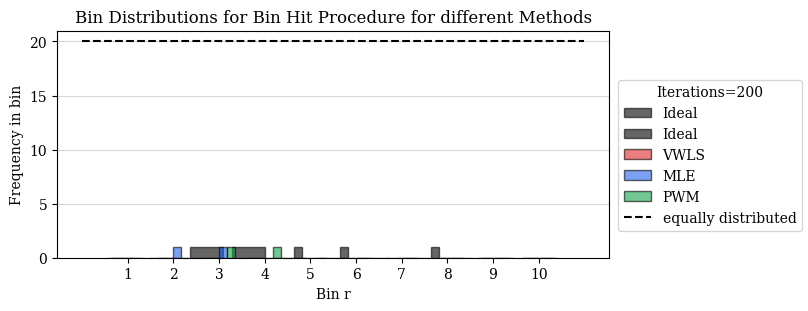

In [12]:
"""Histogram of the data points in each bin"""

save_figures = True
fig,ax=plt.subplots(figsize=(8,3), layout='constrained')


label_list_plot=[
    f'Ideal',
    f'VWLS',
    f'MLE',
    f'PWM'
    ]
#label_list_plot.reverse()
colors_plot=[
    "black",
    my_colors['VWLS'],
    my_colors['MLE'],
    my_colors['PWM']
    ]
#colors_plot.reverse()

#ax.hist(bin_list[0,:200].T, bins=n_bins, range=(0,n_bins), density=False, edgecolor='black', align='right', alpha=0.6, rwidth=0.8, color=colors_plot[0], label=label_list_plot[0])

ax.hist(bin_list[:,-1], bins=n_bins+1, range=(0,n_bins), density=False, edgecolor='black', align='right', alpha=0.6, rwidth=0.8, color=colors_plot[0], label=label_list_plot[0])
ax.hist(bin_list[:,-4:], bins=n_bins, range=(0,n_bins), density=False, edgecolor='black', align='right', alpha=0.6, rwidth=0.7, color=colors_plot[:4], label=label_list_plot[:4])
ax.hlines(y=1/(n_bins)*200, xmin=0, xmax=n_bins+1, colors='black', linestyles='dashed', label=f'equally distributed')
ax.set_xlabel('Bin r')
ax.set_ylabel('Frequency in bin')
ax.set_title('Bin Distributions for Bin Hit Procedure for different Methods')
ax.set_xticks(range(1,n_bins+1))
ax.set_xticklabels([f'{i}' for i in range(1,n_bins+1)])
fig.legend(title=f'Iterations=200', loc="outside right")
ax.grid(axis='y', alpha=0.5)
if save_figures:
    fig.savefig(f"{directory_figures}/bin_hist_fail_gumbel,alpha=10,mu=70,iterations={max_iterations}.png")

In [39]:

#Creating figure 3

directory = "data"
directory_figures="../Figures"
directory_results=directory+"/Results"

true_params_list=[[70,10,0]]
max_iterations=10_000

"""Load params from param_list"""
for true_params in true_params_list:
    mu, alpha, gamma = true_params
    n_bins_array=[10]
    c_array=np.zeros(len(n_bins_array))
    #for each method
    #ideal, vwls, mle, pwm, l_moments


    """loop over bin array"""
    for i_n_bins, n_bins in enumerate(n_bins_array):
        print(f"n_bins: {n_bins}")

        ratio_n_r=np.zeros((n_bins), dtype=float)
        n_r_over_iterations=[]
        n_r=np.zeros((n_bins, 7), dtype=int)
        bin_list=np.empty((max_iterations, 7), dtype=int)

        for iteration in range(0,max_iterations):
            if iteration % 10 == 0:
                print(f"iteration: {iteration}/{max_iterations}",end="\r")
                
            """Generate Data"""
            N = n_bins
            data = genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=N)
            x_new=genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=1)

            """fitting procedure of data"""
            #print(f"Fitting ...")
            
            fit_parameters=[]
            fit_parameters.append(['exact',true_params,0])
            fit_parameters.append(['mu=60',[60,alpha,gamma],0])
            fit_parameters.append(['mu=80',[80,alpha,gamma],0])
            fit_parameters.append(['alpha=5',[mu,5,gamma],0])
            fit_parameters.append(['alpha=15',[mu,15,gamma],0])
            fit_parameters.append(['gamma=-0.3',[mu,alpha,-0.3],0])
            fit_parameters.append(['gamma=0.3',[mu,alpha,0.3],0])

            for z, [method, params, n_points] in enumerate(fit_parameters):
                mu, alpha, gamma= params
                #take next random point and record bin [m-1,m], in which this point falls into
                bin_r=x_in_bin_r(x_new,n_bins,gamma, mu, alpha)
                #print(f"bin_r: {bin_r}")
                if bin_r != -1:
                    n_r[bin_r,z] += 1
                    bin_list[iteration,z] = bin_r
                else:
                    print(f"Data point {x_new} does not fall into any bin.")
                    continue
                """
                n_r_over_iterations.append(n_r.copy())
            #print(f"iteration: {iteration}, n_r: {n_r}\n")
        #ratio_n_r calculated for all bins
        n_r_over_iterations=np.array(n_r_over_iterations)
        #print(n_r_over_iterations)"""
        print("-"*50)

n_bins: 10


--------------------------------------------------


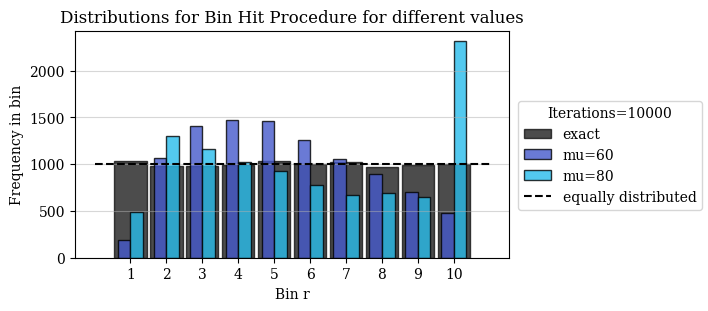

In [ ]:
"""Histogram of the data points in each bin"""

save_figures = True
fig,ax=plt.subplots( figsize=(7,3), layout='constrained')


label_list_plot=[fit_parameters[i][0] for i in range(len(fit_parameters))]
#label_list_plot.reverse()
colors_plot=["black",my_cmap(0.1), my_cmap(0.25), my_cmap(0.4), my_cmap(0.6),my_cmap(0.75), my_cmap(0.9)]
#colors_plot.reverse()

ax.hist(bin_list[:,-1], bins=n_bins, range=(0,n_bins), density=False, edgecolor='black', align='right', alpha=0.7, rwidth=0.9, color=colors_plot[0], label=label_list_plot[0])
ax.hist(bin_list[:,-3:-1], bins=n_bins, range=(0,n_bins), density=False, edgecolor='black', align='right', alpha=0.8, rwidth=0.7, color=colors_plot[1:3], label=label_list_plot[1:3])
ax.hlines(y=1/(n_bins)*max_iterations, xmin=0, xmax=n_bins+1, colors='black', linestyles='dashed', label=f'equally distributed')
ax.set_xlabel('Bin r')
ax.set_ylabel('Frequency in bin')
ax.set_title('Distributions for Bin Hit Procedure for different mu values')
ax.set_xticks(range(1,n_bins+1))
ax.set_xticklabels([f'{i}' for i in range(1,n_bins+1)])
fig.legend(title=f'Iterations={max_iterations}', loc="outside right")
ax.grid(axis='y', alpha=0.5)
if save_figures:
    fig.savefig(f"{directory_figures}/bin_hist_bad_fits_mu_gumbel,alpha=10,mu=70,gamma=0,iterations={max_iterations}.png")

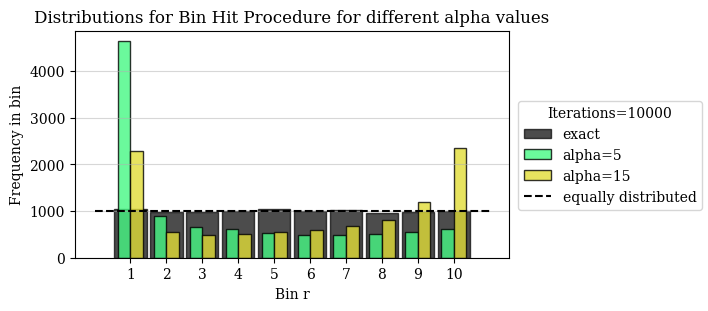

In [52]:
"""Histogram of the data points in each bin"""

save_figures = True
fig,ax=plt.subplots( figsize=(7,3), layout='constrained')


label_list_plot=[fit_parameters[i][0] for i in range(len(fit_parameters))]
#label_list_plot.reverse()
colors_plot=["black",my_cmap(0.1), my_cmap(0.25), my_cmap(0.4), my_cmap(0.6),my_cmap(0.75), my_cmap(0.9)]
#colors_plot.reverse()

ax.hist(bin_list[:,-1], bins=n_bins, range=(0,n_bins), density=False, edgecolor='black', align='right', alpha=0.7, rwidth=0.9, color=colors_plot[0], label=label_list_plot[0])
ax.hist(bin_list[:,-5:-3], bins=n_bins, range=(0,n_bins), density=False, edgecolor='black', align='right', alpha=0.8, rwidth=0.7, color=colors_plot[3:5], label=label_list_plot[3:5])
ax.hlines(y=1/(n_bins)*max_iterations, xmin=0, xmax=n_bins+1, colors='black', linestyles='dashed', label=f'equally distributed')
ax.set_xlabel('Bin r')
ax.set_ylabel('Frequency in bin')
ax.set_title('Distributions for Bin Hit Procedure for different alpha values')
ax.set_xticks(range(1,n_bins+1))
ax.set_xticklabels([f'{i}' for i in range(1,n_bins+1)])
fig.legend(title=f'Iterations={max_iterations}', loc="outside right")
ax.grid(axis='y', alpha=0.5)
if save_figures:
    fig.savefig(f"{directory_figures}/bin_hist_bad_fits_alpha_gumbel,alpha=10,mu=70,gamma=0,iterations={max_iterations}.png")

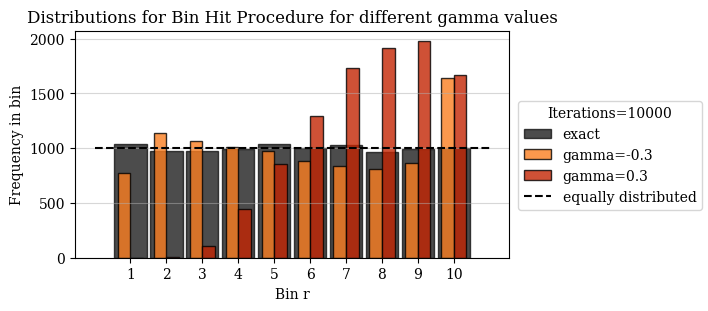

In [51]:
"""Histogram of the data points in each bin"""

save_figures = True
fig,ax=plt.subplots( figsize=(7,3), layout='constrained')


label_list_plot=[fit_parameters[i][0] for i in range(len(fit_parameters))]
#label_list_plot.reverse()
colors_plot=["black",my_cmap(0.1), my_cmap(0.25), my_cmap(0.4), my_cmap(0.6),my_cmap(0.75), my_cmap(0.9)]
#colors_plot.reverse()

ax.hist(bin_list[:,-1], bins=n_bins, range=(0,n_bins), density=False, edgecolor='black', align='right', alpha=0.7, rwidth=0.9, color=colors_plot[0], label=label_list_plot[0])
ax.hist(bin_list[:,-7:-5], bins=n_bins, range=(0,n_bins), density=False, edgecolor='black', align='right', alpha=0.8, rwidth=0.7, color=colors_plot[5:7], label=label_list_plot[5:7])
ax.hlines(y=1/(n_bins)*max_iterations, xmin=0, xmax=n_bins+1, colors='black', linestyles='dashed', label=f'equally distributed')
ax.set_xlabel('Bin r')
ax.set_ylabel('Frequency in bin')
ax.set_title('Distributions for Bin Hit Procedure for different gamma values')
ax.set_xticks(range(1,n_bins+1))
ax.set_xticklabels([f'{i}' for i in range(1,n_bins+1)])
fig.legend(title=f'Iterations={max_iterations}', loc="outside right")
ax.grid(axis='y', alpha=0.5)
if save_figures:
    fig.savefig(f"{directory_figures}/bin_hist_bad_fits_gamma_gumbel,alpha=10,mu=70,gamma=0,iterations={max_iterations}.png")

In [30]:
'creating a plot to show the convergence of the c measure to the equally distributed case for the known parameters'

directory = "data"
directory_figures="../Figures"
directory_results=directory+"/Results"

true_params_list=[[70,10,0]]
max_iterations=np.arange(0,5000,50)
c_array=np.zeros(len(max_iterations))

"""Load params from param_list"""
for true_params in true_params_list:
    mu, alpha, gamma = true_params
    n_bins_array=[10]
    ratio_n_r=np.zeros((n_bins_array[0], len(max_iterations)), dtype=float)
    n_r=np.zeros((n_bins_array[0], len(max_iterations)), dtype=int)


    """loop over bin array"""
    for i_n_bins, n_bins in enumerate(n_bins_array):
        print(f"n_bins: {n_bins}")
    for i_max_iter, max_iter in enumerate(max_iterations):
        #print(f"max_iterations: {max_iter}")

        bin_list=np.empty((max_iter, len(max_iterations)), dtype=int)

        for iteration in range(1,max_iter+1):
            if iteration % 100 == 0:
                print(f"iteration: {iteration}/{max_iter}",end="\r")
                
            """Generate Data"""
            N = n_bins
            data = genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=N)
            x_new=genextreme.rvs(c=-gamma, loc=mu, scale=alpha, size=1)

            """fitting procedure of data"""
            #print(f"Fitting ...")
            
            fit_parameters=[]
            fit_parameters.append([max_iter,true_params,0])

            mu, alpha, gamma= true_params
            #take next random point and record bin [m-1,m], in which this point falls into
            bin_r=x_in_bin_r(x_new,n_bins,gamma, mu, alpha)
            #print(f"bin_r: {bin_r}")
            if bin_r != -1:
                n_r[bin_r,i_max_iter] += 1
                ratio_n_r[bin_r,i_max_iter]=n_r[bin_r,i_max_iter]/iteration
                #bin_list[iteration,i_max_iter] = bin_r
            else:
                print(f"Data point {x_new} does not fall into any bin.")
                continue

            c_array[i_max_iter]=np.sqrt(((ratio_n_r[:,i_max_iter]-1/(n_bins))**2).sum())
        #print("-"*50)

n_bins: 10


TypeError: 'int' object is not subscriptable

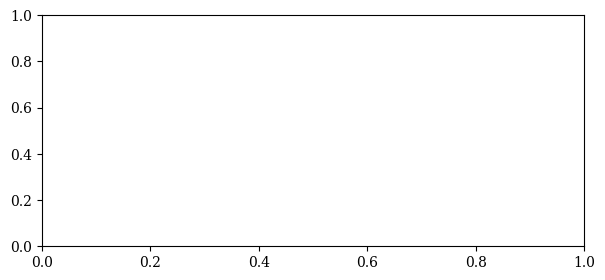

In [40]:
"""Histogram of the data points in each bin"""

save_figures = True
fig,ax=plt.subplots( figsize=(7,3))#, layout='constrained')


ax.plot(max_iterations[1:], c_array[1:],  color='black', label='C measure for 10 bins\n known parameters: mu=70, alpha=10, gamma=0')
ax.hlines(y=0, xmin=max_iterations[0], xmax=max_iterations[-1], colors='black', linestyles='dashed', label=f'bins perfectly equally distributed')
ax.set_xlabel('Max Iterations')
ax.set_ylabel('C measure')
ax.set_title('C measure convergence for known parameters')
ax.grid(alpha=0.5)
ax.legend()
if save_figures:
    fig.savefig(f"{directory_figures}/c_convergence_gumbel,alpha=10,mu=70,gamma=0.png")

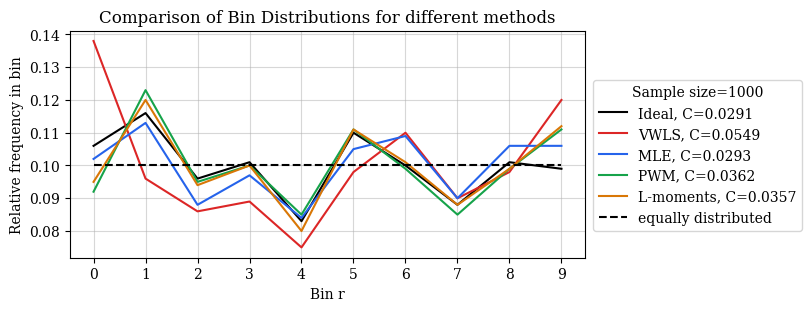

In [65]:
"""Histogram of the data points in each bin"""

fig,ax=plt.subplots(figsize=(8,3), layout='constrained')


label_list_plot=[
    f'Ideal, C={c_array[0]:.4f}',
    f'VWLS, C={c_array[1]:.4f}',
    f'MLE, C={c_array[2]:.4f}',
    f'PWM, C={c_array[3]:.4f}',
    f'L-moments, C={c_array[4]:.4f}'
    ]
colors_plot=[
    my_colors['VWLS'],
    my_colors['VWLS'],
    my_colors['MLE'],
    my_colors['PWM'],
    my_colors['L-moments']
    ]


ax.plot(rel_freq_array[0], label=label_list_plot[0], color='black')
ax.plot(rel_freq_array[1], label=label_list_plot[1], color=colors_plot[1])
ax.plot(rel_freq_array[2], label=label_list_plot[2], color=colors_plot[2])
ax.plot(rel_freq_array[3], label=label_list_plot[3], color=colors_plot[3])
ax.plot(rel_freq_array[4], label=label_list_plot[4], color=colors_plot[4])

ax.hlines(y=1/(n_bins), xmin=0, xmax=n_bins-1, colors='black', linestyles='dashed', label=f'equally distributed')
ax.set_xlabel('Bin r')
ax.set_ylabel('Relative frequency in bin')
ax.set_title('Comparison of Bin Distributions for different methods')
ax.set_xticks(range(0,n_bins))
ax.set_xticklabels(range(0,n_bins))
fig.legend(title=f'Sample size={len(data_subset)}', loc="outside right")
ax.grid(alpha=0.5)
if save_figures:
    fig.savefig(f"{directory_figures}/bin_hist_lines_{filename}.png")